In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# loading data from drive link given
url = "https://drive.google.com/uc?id=1TXoqikmE0S3LGem8Ig-GktaJJyZPGMgN"
df = pd.read_csv(url)

df.head()


,id,sex,birth_year,country,region,group,infection_reason,infection_order,infected_by,contact_number,confirmed_date,released_date,deceased_date,state
0,1,female,1984.0,China,filtered at airport,NaN,visit to Wuhan,1.0,NaN,45.0,2020-01-20,2020-02-06,NaN,released
1,2,male,1964.0,Korea,filtered at airport,NaN,visit to Wuhan,1.0,NaN,75.0,2020-01-24,2020-02-05,NaN,released
2,3,male,1966.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,16.0,2020-01-26,2020-02-12,NaN,released
3,4,male,1964.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,95.0,2020-01-27,2020-02-09,NaN,released
4,5,male,1987.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,31.0,2020-01-30,NaN,NaN,isolated


In [ ]:
# convert date columns
df["confirmed_date"] = pd.to_datetime(df["confirmed_date"])
df["released_date"] = pd.to_datetime(df["released_date"])
df["deceased_date"] = pd.to_datetime(df["deceased_date"])

# make age (approx, assuming year 2020)
df["age"] = 2020 - df["birth_year"]

# see a few important columns
df[["sex", "age", "country", "region", "state"]].head()



,sex,age,country,region,state
0,female,36.0,China,filtered at airport,released
1,male,56.0,Korea,filtered at airport,released
2,male,54.0,Korea,capital area,released
3,male,56.0,Korea,capital area,released
4,male,33.0,Korea,capital area,isolated


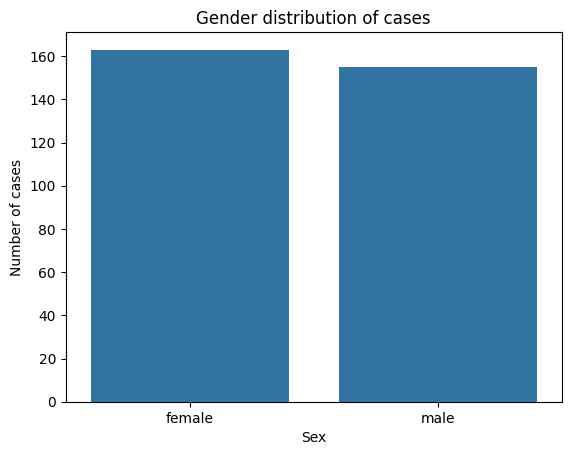

In [ ]:
sns.countplot(data=df, x="sex")
plt.title("Gender distribution of cases")
plt.xlabel("Sex")
plt.ylabel("Number of cases")
plt.show()
# This is the graph for no. of cases in both gender


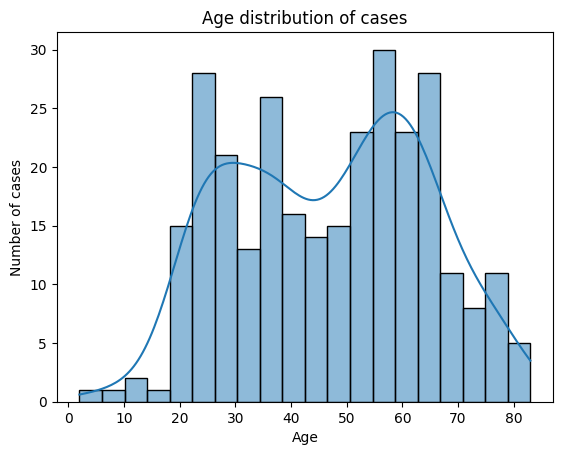

In [ ]:
sns.histplot(df["age"].dropna(), bins=20, kde=True)
plt.title("Age distribution of cases")
plt.xlabel("Age")
plt.ylabel("Number of cases")
plt.show()
# This graph is for age groups of patients


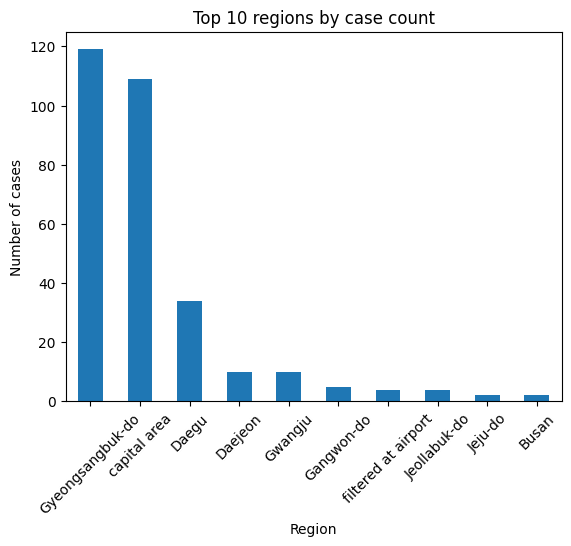

In [ ]:
# top 10 regions by number of cases
region_counts = df["region"].value_counts().head(10)

region_counts.plot(kind="bar")
plt.title("Top 10 regions by case count")
plt.xlabel("Region")
plt.ylabel("Number of cases")
plt.xticks(rotation=45)
plt.show()


In [ ]:
# for keeping only released patients with both confirmed and released dates
rel = df[
    (df["state"] == "released") &
    df["confirmed_date"].notna() &
    df["released_date"].notna()
].copy()

# create recovery duration
rel["days_to_recovery"] = (rel["released_date"] - rel["confirmed_date"]).dt.days

# see some rows
rel[["confirmed_date", "released_date", "days_to_recovery"]].head()


,confirmed_date,released_date,days_to_recovery
0,2020-01-20,2020-02-06,17
1,2020-01-24,2020-02-05,12
2,2020-01-26,2020-02-12,17
3,2020-01-27,2020-02-09,13
5,2020-01-30,2020-02-19,20


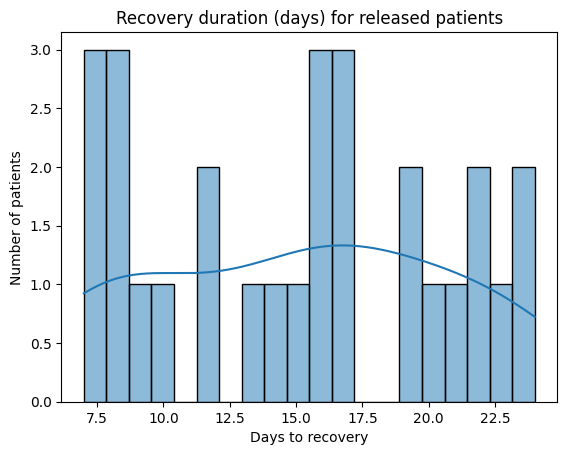

,days_to_recovery
count,28.000000
mean,15.107143
std,5.626256
min,7.000000
25%,9.750000
50%,16.000000
75%,19.250000
max,24.000000


In [ ]:
sns.histplot(rel["days_to_recovery"], bins=20, kde=True)
plt.title("Recovery duration (days) for released patients")
plt.xlabel("Days to recovery")
plt.ylabel("Number of patients")
plt.show()

rel["days_to_recovery"].describe()
# Graph for no. of days to recover


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# use only rows where age and days_to_recovery are available
data_ml = rel[["age", "days_to_recovery"]].dropna()

# input (feature) and output (target)
X = data_ml[["age"]]                  # X is 2D: one column 'age'
y = data_ml["days_to_recovery"]       # y is 1D: days to recover

# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# predict on test set
y_pred = model.predict(X_test)

# evaluate
print("R2 score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("Coefficient (age):", model.coef_[0])
print("Intercept:", model.intercept_)


R2 score: -0.1176630434782604
MAE: 4.840579710144927
Coefficient (age): -0.07608695652173916
Intercept: 18.358695652173914
